<a href="https://colab.research.google.com/github/camilacostav01-oss/AI-in-physics-projects./blob/main/Copia_de_Progetto_AI_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn import tree

from sklearn.model_selection import cross_val_score, train_test_split, LeaveOneOut
from sklearn.utils import resample

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.tree import DecisionTreeClassifier, export_text

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.optimizers import Adam

import seaborn as sns

In [ ]:
Parkinsons_data= pd.read_csv("/content/drive/MyDrive/progetto AI/parkinsons/parkinsons.data")
Parkinsons_data

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [ ]:
X = Parkinsons_data[['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)','RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']]
y = Parkinsons_data["status"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=0.9)
X_train_scaled = pca.fit_transform(X_train_scaled)
X_test_scaled = pca.transform(X_test_scaled)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(zip(np.unique(y_train), weights))
print("Class weights:", class_weight)

Class weights: {np.int64(0): np.float64(2.0526315789473686), np.int64(1): np.float64(0.6610169491525424)}


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau( monitor='val_accuracy', factor=0.5,
                              patience=5, min_lr=1e-6, verbose=1)
  # metriche da monitorare (es. val_loss o val_accuracy)# riduci lr a metà# aspetta 5 epoche senza miglioramento# lr minimo

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define the Early Stopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

print("\nTraining Multilayer Perceptron (MLP)...")
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_mlp = mlp_model.fit(X_train_scaled, y_train, batch_size=8, epochs=100, validation_split=0.1, shuffle='true',
                            class_weight=class_weight, callbacks=[reduce_lr, early_stopping], verbose=0)

loss_mlp, accuracy_mlp = mlp_model.evaluate(X_test_scaled, y_test, verbose=0, batch_size=8)
print(f"MLP Accuracy: {accuracy_mlp:.4f}")


#dimensione dei passi nell'algoritmo di discesa del gradiente, diminuiscono alla fine per cercare più precisamente il minimo. mlp vine addestrato con discesa del gradiente

y_pred_mlp_proba = mlp_model.predict(X_test_scaled, batch_size=8)
y_pred_mlp = (y_pred_mlp_proba >= 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_mlp))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print("Confusion Matrix:")
print(cm_mlp)
#dataset piccolo vuol dire batch piccoli e  epoch grossi, sigmoid e binary crossentropy perchè classificazione binaria
#epoch 100 converge, 20 troppo piccola accuracy


Training Multilayer Perceptron (MLP)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 26: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 36: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 41: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 46: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 51: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 56: ReduceLROnPlateau reducing learning rate to 1e-06.
MLP Accuracy: 0.8974
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy

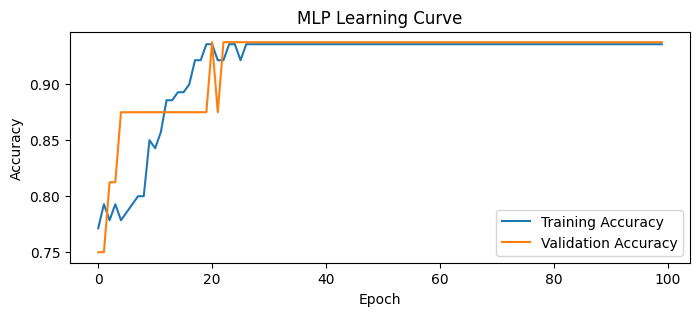

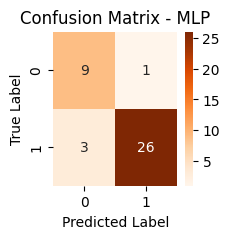

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(history_mlp.history['accuracy'], label='Training Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Validation Accuracy')
plt.title('MLP Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(2, 2))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges',
            xticklabels=np.arange(2), yticklabels=np.arange(2))
plt.title('Confusion Matrix - MLP')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
plt.close()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np

# Combine X and y for k-fold cross-validation
X_combined = Parkinsons_data[['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)','RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']].values
y_combined = Parkinsons_data["status"].values

# Define the number of folds
n_splits = 5 # You can choose a different number of folds (e.g., 5 or 10)

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# List to store accuracy scores for each fold
fold_accuracies = []

print(f"Performing {n_splits}-fold cross-validation...")

# Loop through each fold
for fold, (train_index, val_index) in enumerate(skf.split(X_combined, y_combined)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    # Split data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_combined[train_index], X_combined[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    # Scale the data within the fold to prevent data leakage
    scaler_fold = StandardScaler()
    X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler_fold.transform(X_val_fold)

    # Define and compile a new instance of the MLP model for each fold
    mlp_model_fold = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_fold_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    mlp_model_fold.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model for the current fold
    # You can add Early Stopping here as well if desired
    history_fold = mlp_model_fold.fit(X_train_fold_scaled, y_train_fold,
                                      epochs=100,  # You can adjust the number of epochs
                                      batch_size=8, # You can adjust the batch size
                                      verbose=0) # Set verbose to 1 to see training progress per epoch

    # Evaluate the model on the validation data for the current fold
    loss_fold, accuracy_fold = mlp_model_fold.evaluate(X_val_fold_scaled, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {accuracy_fold:.4f}")

    # Store the accuracy
    fold_accuracies.append(accuracy_fold)

# Calculate and print the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Cross-Validation Accuracy: {average_accuracy:.4f}")
print(f"Standard Deviation of Accuracy: {np.std(fold_accuracies):.4f}")